# Check ACE Quality
Load a specific SUNO song, compare chord labels vs pre-computed functional harmony, show beats, and play the audio.

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import librosa
import music21

from IPython.display import Audio, display

sys.path.append("/workspace/src")
import plotMe as pm

## 1. Locate Target Song

In [2]:
song_id = "000364ba-26f7-44d5-9698-b75e322dc8a1"
collection = "suno"
DATASET_BASE = "/workspace/dataset"
AUDIO_BASE = f"/mnt/Aimir_HD/{collection}/audio"

song_dir = f"{DATASET_BASE}/{collection}/{song_id}"
lab_path = f"{song_dir}/{song_id}.lab"
functional_lab_path = f"{song_dir}/{song_id}_functional.lab"
analysis_path = f"{song_dir}/{song_id}_analysis.json"
audio_path = f"{AUDIO_BASE}/{song_id}.mp3"

print("Song ID:", song_id)
print("LAB exists:", os.path.exists(lab_path))
print("Functional LAB exists:", os.path.exists(functional_lab_path))
print("Analysis exists:", os.path.exists(analysis_path))
print("Audio exists:", os.path.exists(audio_path))

Song ID: 000364ba-26f7-44d5-9698-b75e322dc8a1
LAB exists: True
Functional LAB exists: True
Analysis exists: True
Audio exists: True


## 2. Load Chord & Functional Harmony Annotations

In [3]:
def parse_lab_file(path):
    """Parse a .lab file into a list of {start, end, label} dicts."""
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) < 3:
                continue
            start = float(parts[0])
            end = float(parts[1])
            label = parts[2]
            rows.append({"start": start, "end": end, "label": label})
    return rows

# --- Read chord labels ---
if not os.path.exists(lab_path):
    raise FileNotFoundError(f"Missing LAB file: {lab_path}")
lab_rows = parse_lab_file(lab_path)

# --- Read pre-computed functional harmony ---
if not os.path.exists(functional_lab_path):
    raise FileNotFoundError(f"Missing functional LAB file: {functional_lab_path}")
functional_rows = parse_lab_file(functional_lab_path)

# --- Read analysis JSON (beats, structure) ---
analysis = None
beats = []
structure_data = None
if os.path.exists(analysis_path):
    try:
        with open(analysis_path, "r") as f:
            analysis = json.load(f)
        beats = analysis.get("beats", [])
        if all(key in analysis for key in ["bound_frames", "bound_segments", "beats", "sr"]):
            structure_data = {
                "bound_frames": analysis["bound_frames"],
                "bound_segments": analysis["bound_segments"],
                "beats": analysis["beats"],
                "sr": analysis["sr"],
            }
    except Exception as e:
        print("Warning: failed to read analysis JSON:", e)

# --- Build a lookup: start time -> functional label ---
func_lookup = {}
for row in functional_rows:
    func_lookup[round(row["start"], 3)] = row["label"]

# --- Merge chord labels with functional harmony ---
beat_times = np.array(beats, dtype=float) if beats else None

chords = []
for idx, row in enumerate(lab_rows):
    start = row["start"]
    end = row["end"]
    label = row["label"]

    # Match functional label by start time (rounded to 3 decimals)
    rn = func_lookup.get(round(start, 3), "")

    if beat_times is not None and len(beat_times) > 0:
        beat_idx = int(np.argmin(np.abs(beat_times - start)))
        beat_idx_end = int(np.argmin(np.abs(beat_times - end)))
        if beat_idx_end < beat_idx:
            beat_idx_end = beat_idx
    else:
        beat_idx = idx
        beat_idx_end = idx + 1

    chords.append({
        "beat_start": start,
        "beat_end": end,
        "beat_idx": beat_idx,
        "beat_idx_end": beat_idx_end,
        "chord_name": label,
        "functional_harmony": {
            "roman_numeral": rn,
            "functional": rn,
            "alterations": "",
        },
    })

# --- Build DataFrame for display ---
rows_df = []
for chord in chords:
    fh = chord.get("functional_harmony", {})
    rows_df.append({
        "start": chord["beat_start"],
        "end": chord["beat_end"],
        "label": chord["chord_name"],
        "functional": fh.get("functional", ""),
    })

chords_df = pd.DataFrame(rows_df)
print(f"Chord rows: {len(chords_df)}  |  Functional matches: {(chords_df['functional'] != '').sum()}")
print(f"Beats loaded: {len(beats)}  |  Structure data: {structure_data is not None}")
chords_df.head(10)

Chord rows: 104  |  Functional matches: 102
Beats loaded: 249  |  Structure data: True


,start,end,label,functional
0,0.000000,1.299304,C#:min,vi
1,1.299304,2.459397,A:maj,IV
2,2.459397,3.573086,E:maj,I
3,3.573086,4.733179,B:maj,V
4,4.733179,5.870070,C#:min,vi
5,5.870070,7.030162,A:maj,IV
6,7.030162,8.143852,E:maj,I
7,8.143852,9.373550,B:maj,V
8,9.373550,10.440835,C#:min,vi
9,10.440835,11.624130,A:maj,IV


## 3. Visualize Chords: Labels vs Functional Harmony

done


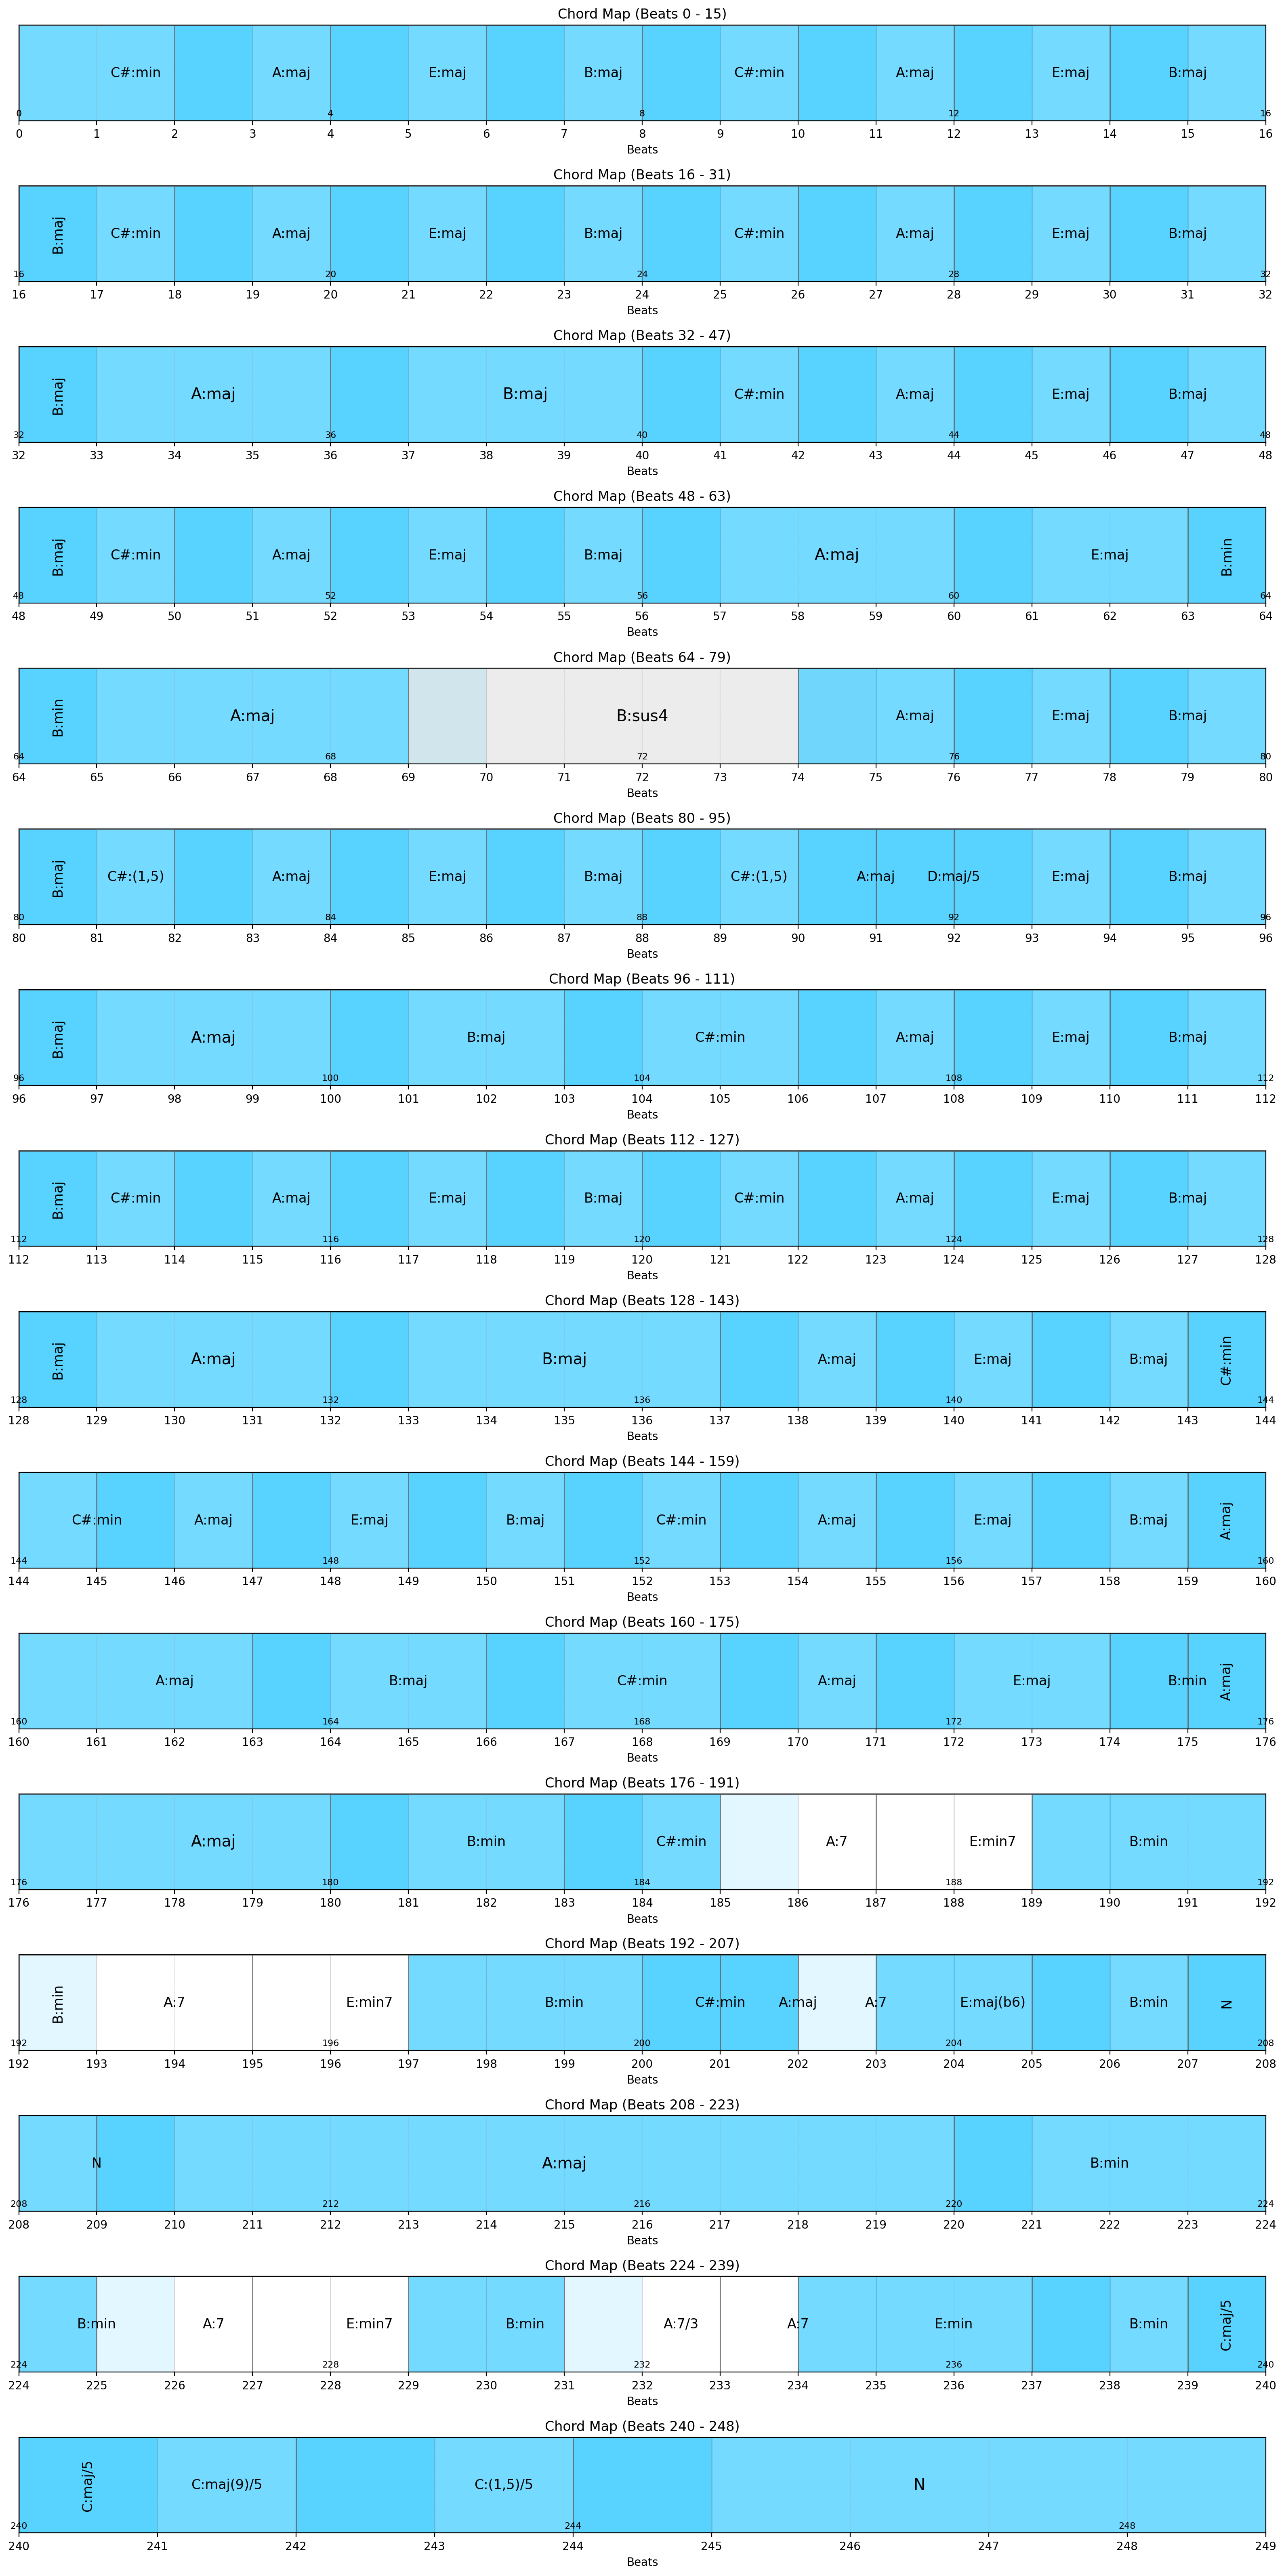

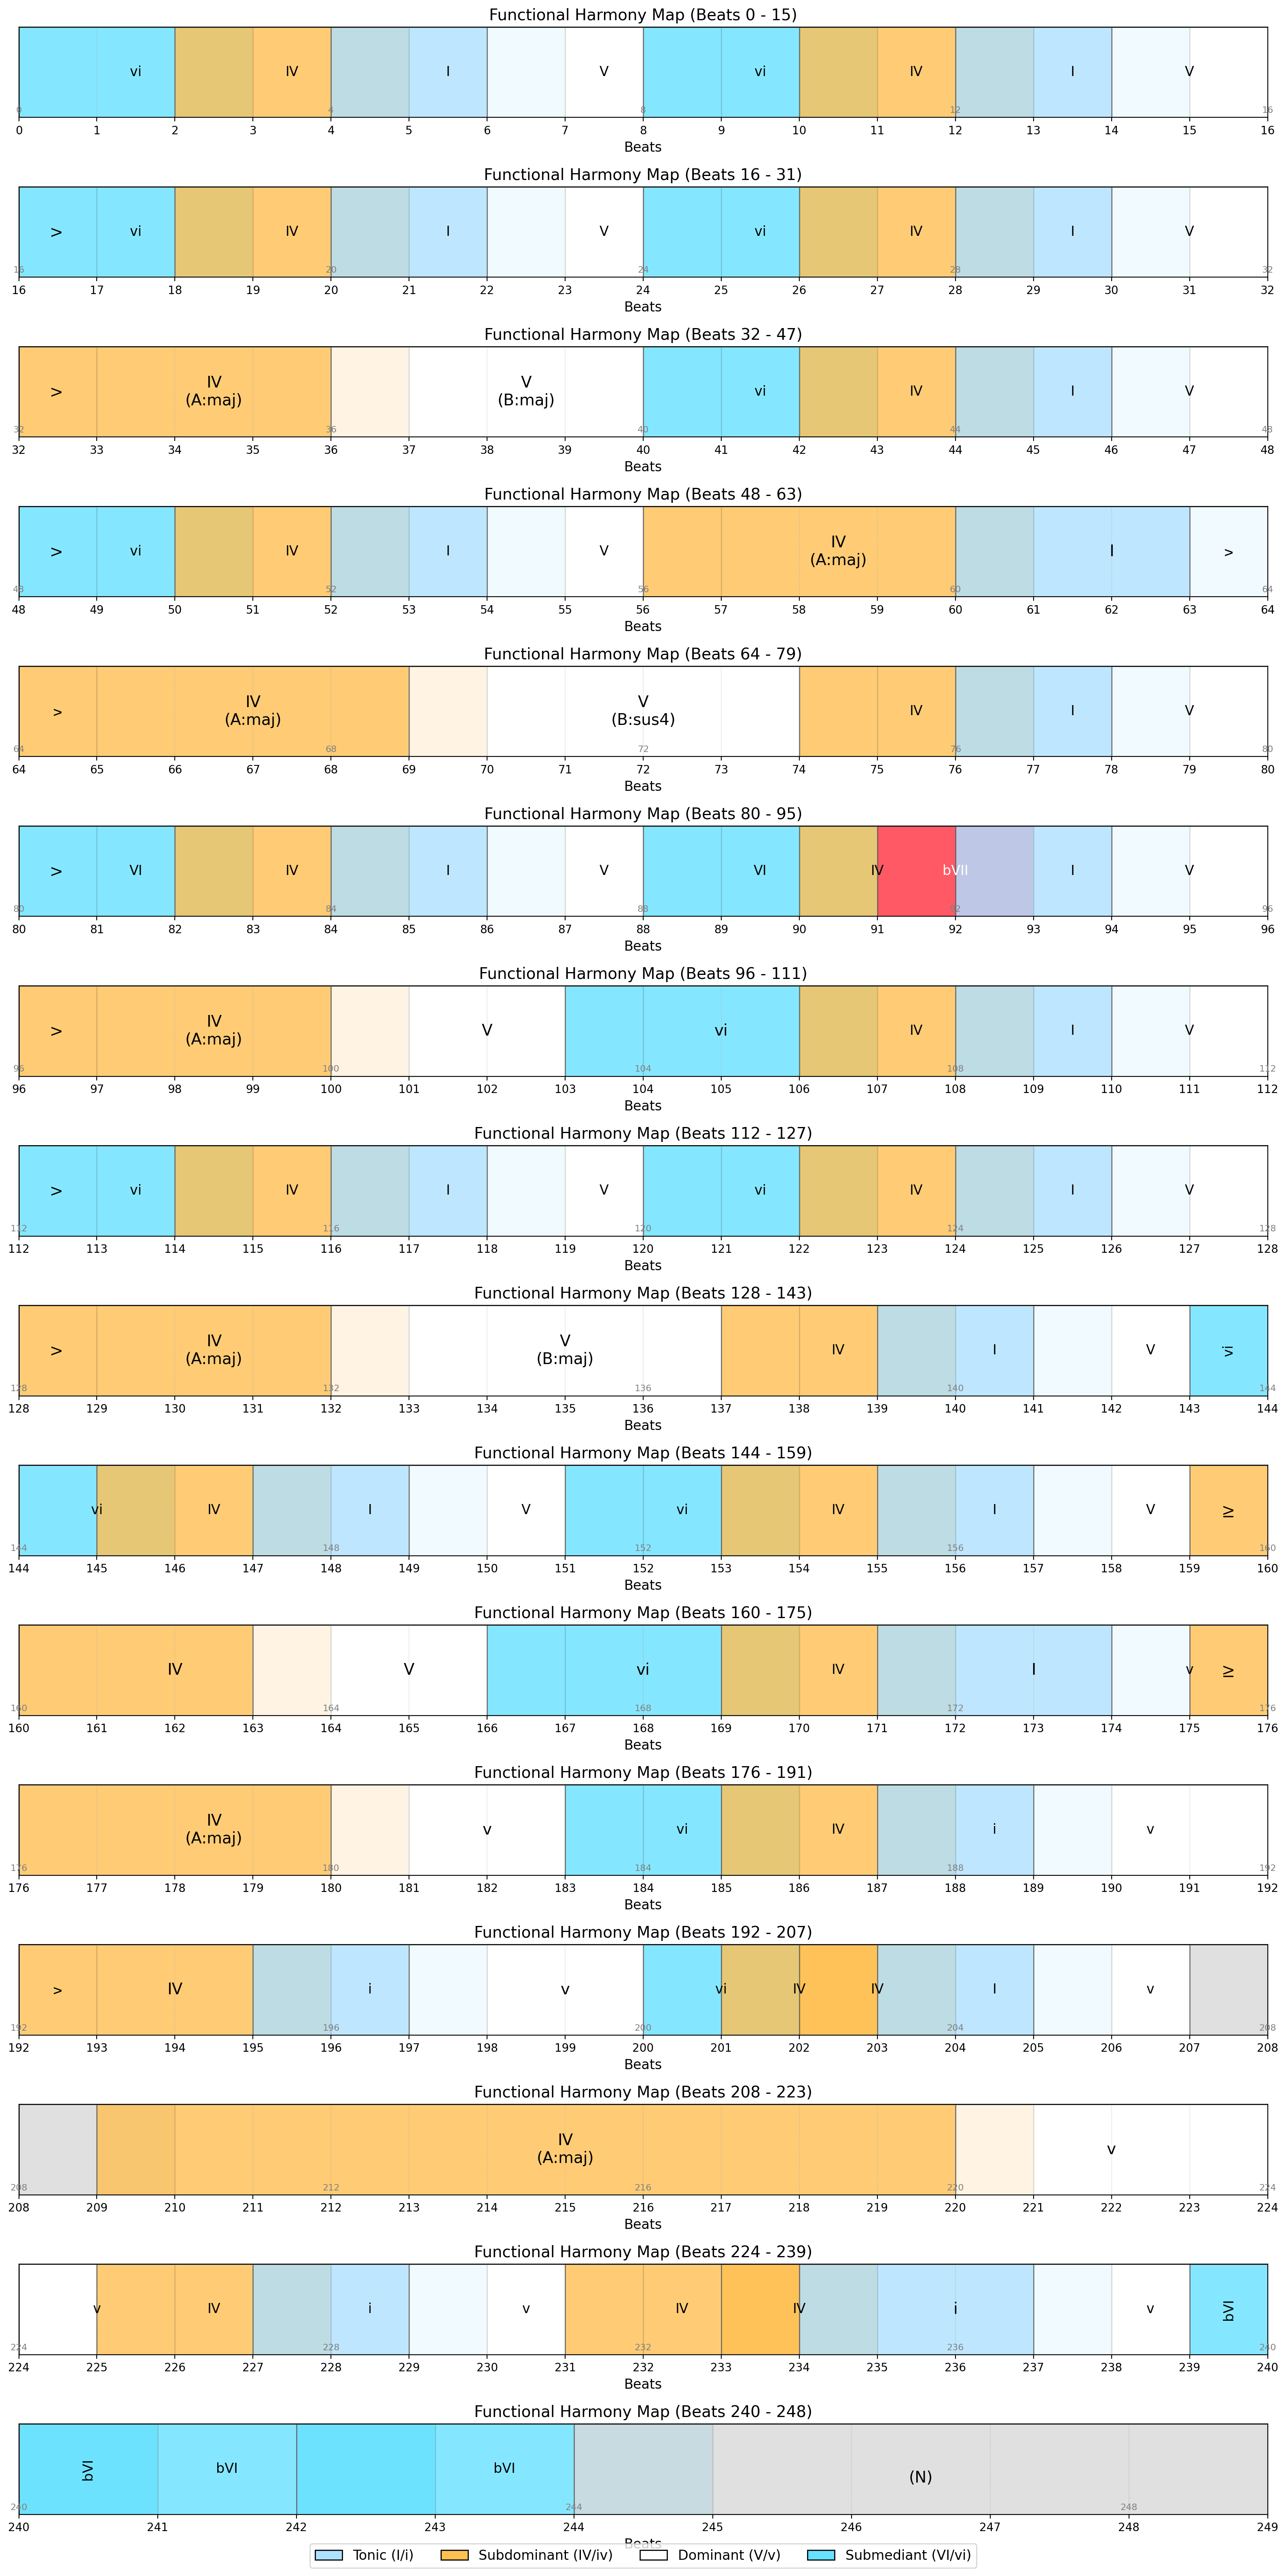

In [4]:
pm.plot_chord_score_map(chords, beats_per_row=16)
pm.plot_functional_harmony_map(chords, beats_per_row=16)
print("done")

## 5. Inline Audio Playback from /mnt/Aimir_HD/suno/audio

In [5]:
if os.path.exists(audio_path):
    display(Audio(audio_path))
else:
    print("Audio file not found:", audio_path)
    print("If audio is outside the container, mount it and update AUDIO_BASE.")